
### **Chapter 6.2: Learning-based Model Predictive Control**

In this chapter, we introduce the motivation and structure of learning-based model predictive control (MPC) under uncertainty. When the true system dynamics are unknown or difficult to model exactly, we rely on data-driven approaches to build approximate models and design robust controllers.

We start by setting up a bumpy terrain case as the simulation environment, and specifying all task parameters. This provides a unified testbed for comparing different control strategies. Then we provide auxiliary functions for basis generation and symbolic model construction. These tools are essential for flexible model learning and controller synthesis. Based on all these preparations, we can develop different controllers and run the simulation according to different levels of prior knowledge about the real environment. This process proceeds through multiple key stages: 

- **Baseline 1:** Simulate MPC designed with the true model (bumpy case) to establish a baseline.

- **Baseline 2:** Simulate MPC designed with a mismatched model (flat case) and compare with the first example to illustrate the impact of model mismatch.

- **Deterministic learning:** Collect data, identify a deterministic model using **linear regression**, and simulate MPC designed with the learned model to demonstrate data-driven control without uncertainty quantification.

- **Probabilistic learning (Robust MPC):** Assume a mismatched model (flat case) and uncertainty bounds and implement **RMPC** to handle model uncertainty conservatively.

- **Probabilistic learning (Bayesian):** Collect data, identify a probabilistic model using **Bayesian linear regression**, and simulate **learning-based MPC (LBMPC)** with uncertainty quantification, enabling constraint tightening and risk-aware control.

- **Advanced probabilistic learning (GP vs. BLR):** Compare **Gaussian process (GP) regression** with **Bayesian linear regression (BLR)** on the same data, to show that with the right model structure it is easier to generalize beyond the training data, including obtaining a reliable **probabilistic bound estimate** that widens where the model is genuinely uncertain, rather than staying overconfident.

By the end of this chapter, you will understand how to formulate, implement, and analyze both deterministic and probabilistic model learning techniques, and how they integrate into advanced MPC frameworks for uncertain systems.

The content is summarized in the table below.

<style>
  table td:nth-child(2) {
    text-align: left;
  }
</style>

<table border="1" style="border-collapse: collapse;">  <!-- Title Row -->
  <tr>
    <th colspan="2" style="text-align:center">Chapter 6.2</th>
  </tr>

  <!-- Row group 2 -->
  <tr>
    <td rowspan="2">Baselines without Uncertainty Handling</td>
    <td>Example 1.1: Baseline MPC under Perfect Model Assumption</td>
  </tr>
  <tr>
    <td>Example 1.2: MPC under Model Mismatch with Flat Terrain Assumption</td>
  </tr>

  <!-- Row group 3 -->
  <tr>
    <td rowspan="1">Deterministic Model Learning and Control</td>
    <td>Example 2.1: MPC with Learned Deterministic Model from Data</td>
  </tr>

  <!-- Row group 4 -->
  <tr>
    <td rowspan="2">Probabilistic Model Learning and Control</td>
    <td>Example 3.1: Robust MPC with Flat Model and Bounded Uncertainty</td>
  </tr>
  <tr>
    <td>Example 3.2: Learning-Based MPC via Bayesian Model Identification</td>
  </tr>

  <!-- Row group 5 -->
  <tr>
    <td rowspan="2">Advanced Model Learning and Control</td>
    <td>Example 4.1: Comparing GP and Bayesian Linear Regression for Model Learning</td>
  </tr>
  <tr>
    <td>Example 4.2: Model Learning When the Basis Is Misspecified</td>
  </tr>
  <tr>
    <td>Example 4.3: GP-Based MPC (GP-MPC) in Closed-Loop Simulation</td>
  </tr>

</table>

<br>

First, we need to set up our Python environment and import relevant packages.

In [40]:
import sys
import os
import numpy as np
from acados_template import  AcadosModel, AcadosOcp, AcadosOcpSolver

sys.path.append(os.path.abspath(".."))
from utils.env import *
from utils.simulator import *
from ex2_LQR.lqr_utils import *
from ex5_MPC.mpc_utils import *
from ex6_SysID.SysID_utils import *

<br>

### **Experimental Setup and Unified Benchmark for Uncertain Terrain Control**

In this chapter, we address the challenge of controlling a mountain car system when the true environment is uncertain and potentially complex. Specifically, we assume that the real testbed is a bumpy terrain $h(p) = k \cdot \cos(18 p)$ (case 3), but as a controller designer, you do not know the exact profile of the terrain. Instead, you are aware that there is some uncertainty in the system dynamics, and your goal is to design controllers that can handle this uncertainty effectively.

To systematically study and compare different control strategies, we establish a unified simulation testbed. This testbed allows us to specify all relevant task parameters and use them consistently across all examples in the chapter. By doing so, we can fairly evaluate the performance of various approaches, from ideal model-based control to learning-based and robust controllers.

- Simulation parameters:  

   - Case index of testbed: case 3 (bumpy terrain) with parameter $k = 0.01$

   - Control frequency: 10 Hz 

   - Simulation time: 8 seconds.

- Task parameters:  

   - initial state: $\boldsymbol{x}_0 = [-0.5, 0.0]^\top$

   - target state: $\boldsymbol{x}_T = [0.5, 0.0]^\top$

   - State constraints: $ \quad p \in [-2.0, 2.0], \quad v \in [-4.0, 4.0]$  

   - Input constraints: $ \quad a \in [-8.0, 8.0]$.  

- Controller parameters:  

   - Prediction horizon: $N = 20$
   
   - State cost matrix: $\boldsymbol{Q} = \text{diag}([5, 5])$  

   - Input cost matrix: $\boldsymbol{R} = 0.1$  

   - Terminal cost matrix: $\boldsymbol{Q}_f = \boldsymbol{Q}$.


These parameters define the environment and control objectives for all subsequent simulations and experiments in this chapter.

In [41]:
# Define the test case
case_real = 3

# Define the parameters of the slope
terrain_param = 0.01

# Define task parameters
initial_position = -0.5
initial_velocity = 0.0
target_position = 0.5
target_velocity = 0.0

# Define the physical boundary condition
state_lbs = np.array([-2.0, -4.0])
state_ubs = np.array([2.0, 4.0])
input_lbs = -8.0
input_ubs = 8.0

# Define the parameters in the controller
N = 20
Q = np.diag([5, 5])
R = np.array([[0.1]])
Qf = Q

# Define parameters for simulation
freq = 10 # control frequency
t_terminal = 8 # time length of simulation

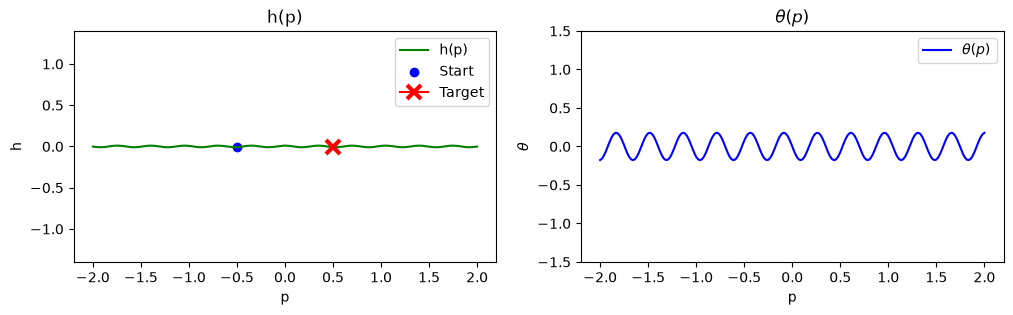

In [42]:
# Instantiate class 'Env'
env_real = Env(case_real, np.array([initial_position, initial_velocity]), np.array([target_position, target_velocity]),
          param=terrain_param, state_lbs=state_lbs, state_ubs=state_ubs, input_lbs=input_lbs, input_ubs=input_ubs)
env_real.test_env()

# Instantiate class 'Dynamics'
dynamics_real = Dynamics(env_real)

<br>

### **Auxiliary Functions for Generating the Symbolic Expression of the Identified Model**

The first utility function **`generate_basis_functions`** simplifies the construction of basis sets for regression by allowing you to automatically generate combinations of polynomial and trigonometric functions with configurable orders and frequencies.  

**Arguments:**  

- `include_offset`: Whether to include the constant bias term $ \phi(p) = 1 $

- `include_polynomial`: Whether to include polynomial terms $ p^i $

- `include_trigonometric`: Whether to include trigonometric terms $ \sin(k p) $, $ \cos(k p) $

- `min_poly_order`, `max_poly_order`: Range of polynomial degrees $ i $

- `min_freq`, `max_freq`: Range of trigonometric frequencies $ k $

- `casadi_sym`: Whether to generate CasADi symbolic expressions of the basis functions

**Returns:**  

- `basis`: List of callable basis functions $\{ \phi_1(p), ... , \phi_B(p) \}$. Each basis function accepts a NumPy array of shape `(D, 1)` or `(D,)` and returns a transformed column vector of shape `(D, 1)`.

- `p_sym`: Symbolic variable (later used in construction of the symbolic identified model)  

- `basis_syms`: List of symbolic expressions of the basis functions $\{ \phi_1(p), ... , \phi_B(p) \}$ (later used in construction of the symbolic identified model)  

In [43]:
def generate_basis_functions(include_offset=True,
                              include_polynomial=True,
                              include_trigonometric=True,
                              min_poly_order=1,
                              max_poly_order=10,
                              min_freq=1,
                              max_freq=10,
                              casadi_sym=True):
    
    """
    Generate a list of basis functions for use in linear regression or Bayesian regression.

    Parameters:
    - include_offset: whether to include the constant 1 term
    - include_polynomial: whether to include polynomial terms p^i
    - include_trigonometric: whether to include sin(kp) and cos(kp) terms
    - min_poly_order: lowest polynomial degree to include
    - max_poly_order: highest polynomial degree to include
    - min_freq: lowest frequency k for trig functions
    - max_freq: highest frequency k for trig functions
    - casadi_sym: if set to be True, use this symbolic variable for generating symbolic basis functions (based on CasADi)

    Returns:
    - basis: a list of callable functions, each \\phi(\\xi) taking \\xi as (D, 1) or (D,) array
    - basis_syms: a list of symbolic expressions for each basis function, if casadi_sym is provided, else None
    """
    
    basis = []
    # If using symbolic computation with CasADi, initialize symbolic variables
    if casadi_sym:
        p_sym = ca.MX.sym("p")
        basis_syms = []
    else:
        basis_syms = None

    # Offset term
    if include_offset:
        basis.append(lambda p: np.ones_like(p))
        # If using symbolic computation with CasADi, add the symbolic constant
        if casadi_sym:
            basis_syms.append(1)

    # Polynomial terms
    if include_polynomial:
        for i in range(min_poly_order, max_poly_order + 1):
            basis.append(lambda p, i=i: p**i)
        # If using symbolic computation with CasADi, add the symbolic polynomial terms
        if casadi_sym:
            for i in range(min_poly_order, max_poly_order + 1):
                basis_syms.append(p_sym ** i)

    # Trigonometric terms
    if include_trigonometric:
        for k in range(min_freq, max_freq + 1):
            basis.append(lambda p, k=k: np.sin(k * p))
            basis.append(lambda p, k=k: np.cos(k * p))
        # If using symbolic computation with CasADi, add the symbolic trigonometric terms
        if casadi_sym:
            for k in range(min_freq, max_freq + 1):
                basis_syms.append(ca.sin(k * p_sym))
                basis_syms.append(ca.cos(k * p_sym))

    return basis, p_sym, basis_syms

<br>

The second function **`construct_casadi_expression`** constructs a CasADi symbolic function for the learned model, combining basis functions and regression weights. It can also provide a function for the predictive variance if uncertainty information is available.  

**Arguments:**  

- `p_sym`: CasADi symbolic variable of independent variable $p$ 

- `basis_syms`: List of symbolic basis expressions $\{ \phi_1(p), ... , \phi_B(p) \}$

- `theta`: Regression weights $\hat{\mu}_\theta$ (attained from **LR** or **BLR**)

- `Sigma_theta` (only for **BLR**): Covariance of weights $\hat{\Sigma}_\theta$ (attained from **BLR**)

- `sigma2_prior` (only for **BLR**): Prior noise variance $\sigma^2$

**Returns:**  

- `h_func`: CasADi function for the mean prediction $\hat{\mu}_{h}(p^*) = \hat{\mu}_\theta^\top \phi(p^*)$

- `sigma2_h` (only for **BLR**): CasADi function for the predictive variance matrix $\hat{\sigma}^2_{h}(p^*) = \sigma^2 + \phi(p^*)^\top \hat{\Sigma}_\theta \phi(p^*)$
    

In [44]:
def construct_casadi_expression(p_sym, basis_syms, theta, Sigma_theta=None, sigma2_prior=None):
    """
    Construct a CasADi symbolic function for h(p) = sum_i theta_i * phi_i(p)

    Parameters:
    - p_sym: CasADi symbolic variable representing the input
    - theta: numpy array of shape (D, 1) or (D,) from Identifier_LR
    - basis_syms: list of CasADi symbolic expressions for each basis function
    - Sigma_theta: optional covariance matrix for Bayesian regression (D, D)
    - sigma2_prior: optional prior variance for Bayesian regression (scalar)

    Returns:
    - h_func: CasADi Function that maps p → h(p)
    - sigma2_h: CasADi Function that maps p → Var[h(p)], or None
    - sigma2_dh: CasADi Function that maps p → Var[h'(p)], or None

    The last output is needed to propagate uncertainty through the dynamics, which
    depend on h only through the inclination theta(p) = atan(h'(p)). For a model that
    is linear in the parameters, differentiating h(p) = phi(p)^T theta with respect to
    p gives h'(p) = phi'(p)^T theta, so Var[h'(p)] = phi'(p)^T Sigma_theta phi'(p).
    Note that this is not the derivative of Var[h(p)], which is a different quantity.
    """
    
    # Ensure basis_syms is concatenated into a vector expression
    Phi_sym = ca.vertcat(*basis_syms)

    # Compute h(p) expression
    h_expr = ca.dot(Phi_sym, theta)  # same as sum(theta[i] * phi_i)

    # Define CasADi function for mean
    h_func = ca.Function("h_post", [p_sym], [h_expr])

    # Define CasADi functions for the variances if required
    if Sigma_theta is not None and sigma2_prior is not None:
        Sigma_expr = ca.mtimes([Phi_sym.T, ca.DM(Sigma_theta), Phi_sym]) + ca.DM(sigma2_prior)
        sigma2_h = ca.Function("sigma2_h_post", [p_sym], [Sigma_expr])

        # Variance of the slope: differentiate the basis, not the variance
        dPhi_sym = ca.jacobian(Phi_sym, p_sym)
        dSigma_expr = ca.mtimes([dPhi_sym.T, ca.DM(Sigma_theta), dPhi_sym])
        sigma2_dh = ca.Function("sigma2_dh_post", [p_sym], [dSigma_expr])
    else:
        sigma2_h = None
        sigma2_dh = None

    return h_func, sigma2_h, sigma2_dh

<br>

----

### **Part 1: Baselines without Uncertainty Handling**

To understand the necessity of handling model uncertainty in the control design, we begin by establishing baseline scenarios where uncertainty is either absent or ignored. In this part, we first examine the ideal case where the controller has full knowledge of the true environment, serving as an upper bound for performance. We then contrast this with a naive design that assumes a simplified, mismatched model, revealing the degradation in performance that arises when uncertainty is neglected. These baselines provide valuable context for evaluating the benefits of more sophisticated, uncertainty-aware controllers in subsequent sections.

<br>

#### **Example 1.1: Baseline MPC under Perfect Model Assumption**

In this example, we assume full knowledge of the true terrain profile. We simulate MPC designed with the true model (case 3) to establish a baseline. This serves as the ideal scenario, providing a reference for evaluating the impact of model mismatch and learning-based approaches in subsequent examples.

field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.
External functions generated in 1.084 ms.
Templated solver code generated in 790.692 ms.
rm -f libacados_ocp_solver_ocp_MPC_baseline_20260825_161854_7075c39b.dylib
rm -f acados_solver_ocp_MPC_baseline_20260825_161854_7075c39b.o
cc -fPIC -std=c99   -O2 -I/Users/siqizhou/.acados/include -I/Users/siqizhou/.acados/include/acados -I/Users/siqizhou/.acados/include/blasfeo/include -I/Users/siqizhou/.acados/include/hpipm/include  -c -o acados_solver_ocp_MPC_baseline_20260825_161854_7075c39b.o acados_solver_ocp_MPC_baseline_20260825_161854_7075c39b.c
cc -fPIC -std=c99   -O2 -I/Users/siqizhou/.acados/include -I/Users/siqizhou/.acados/include/acados -I/Users/siqizhou/.acados/include/blasfeo/include -I/Users/siqizhou/.acados/include/hpipm/include  -c -o MPC_baseline_20260825_161854_model/MPC_baseline_20260825_16185

ld: warning: search path '-l' not found


Simulation finished, will start plotting


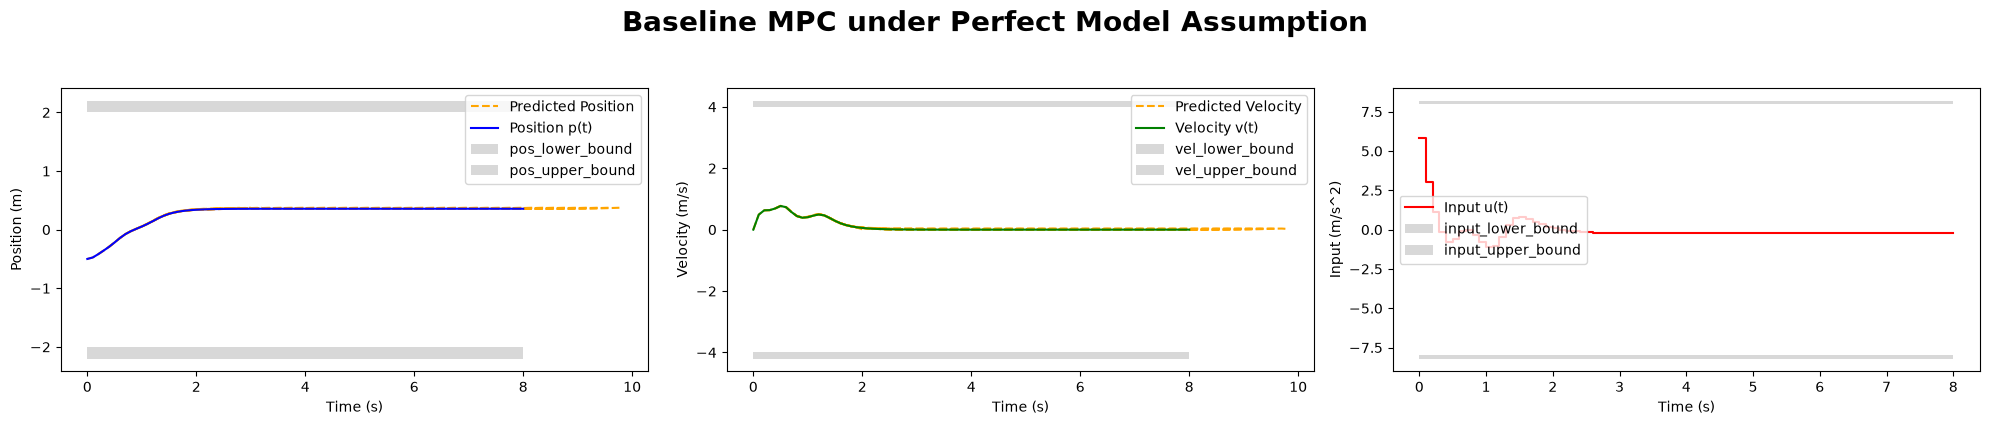

In [45]:
# Define the MPC controller
controller_mpc_ideal = MPCController(env_real, dynamics_real, Q, R, Qf, freq, N, name='MPC_baseline', verbose=False)

# Instantiate the simulator, run the simulation, and plot the results
simulator_mpc_ideal = Simulator(dynamics_real, controller_mpc_ideal, env_real, 1/freq, t_terminal)
simulator_mpc_ideal.run_simulation()

# Instantiate the visualizer, and display the plots and animation
visualizer_mpc_ideal = Visualizer(simulator_mpc_ideal)
visualizer_mpc_ideal.display_plots("Baseline MPC under Perfect Model Assumption")
visualizer_mpc_ideal.display_animation()

<br>

#### **Example 1.2: MPC under Model Mismatch with Flat Terrain Assumption**

In this example, we consider the scenario where the controller designer does not have access to the true terrain profile. Instead, the designer assumes a **simplified, flat terrain model** (case 1) for controller synthesis. We simulate MPC designed with this mismatched (flat) model and apply it to the real bumpy environment. By comparing the results with the ideal baseline (where the true model is known), we can clearly illustrate the impact of model mismatch on control performance and highlight the necessity of accounting for model uncertainty in practical applications.

In [46]:
case_ideal = 1 # 1 or 2 or 3 or 4

# Ideal case for controller design
env_ideal = Env(case_ideal, np.array([initial_position, initial_velocity]), np.array([target_position, target_velocity]),
                 param=terrain_param, state_lbs=state_lbs, state_ubs=state_ubs, input_lbs=input_lbs, input_ubs=input_ubs)
dynamics_ideal = Dynamics(env_ideal)


field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.
External functions generated in 0.867 ms.
Templated solver code generated in 774.318 ms.
rm -f libacados_ocp_solver_ocp_MPC_flat_terrain_model_20260825_161857_21e299f7.dylib
rm -f acados_solver_ocp_MPC_flat_terrain_model_20260825_161857_21e299f7.o
cc -fPIC -std=c99   -O2 -I/Users/siqizhou/.acados/include -I/Users/siqizhou/.acados/include/acados -I/Users/siqizhou/.acados/include/blasfeo/include -I/Users/siqizhou/.acados/include/hpipm/include  -c -o acados_solver_ocp_MPC_flat_terrain_model_20260825_161857_21e299f7.o acados_solver_ocp_MPC_flat_terrain_model_20260825_161857_21e299f7.c
cc -fPIC -std=c99   -O2 -I/Users/siqizhou/.acados/include -I/Users/siqizhou/.acados/include/acados -I/Users/siqizhou/.acados/include/blasfeo/include -I/Users/siqizhou/.acados/include/hpipm/include  -c -o MPC_flat_terrain_model

ld: warning: search path '-l' not found


Simulation finished, will start plotting


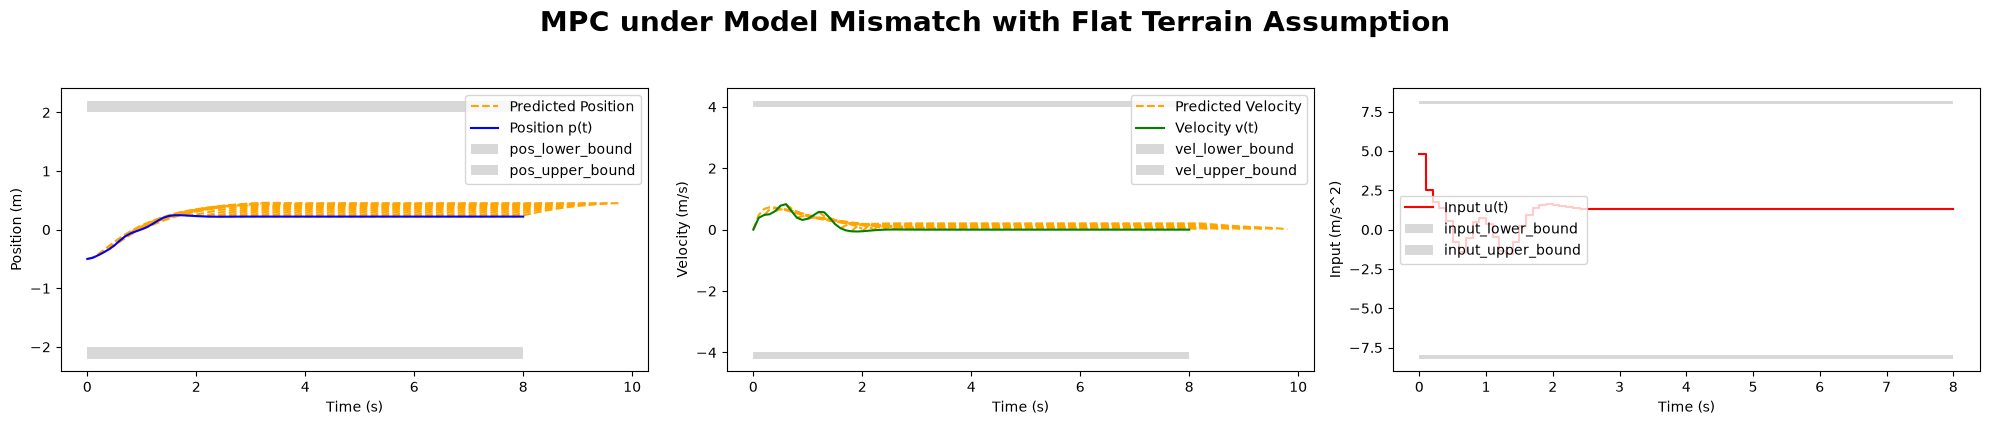

In [47]:
# Define the MPC controller
controller_mpc_real = MPCController(env_ideal, dynamics_ideal, Q, R, Qf, freq, N, name='MPC_flat_terrain_model', verbose=False)

# Instantiate the simulator, run the simulation, and plot the results
simulator_mpc_real = Simulator(dynamics_real, controller_mpc_real, env_real, 1/freq, t_terminal)
simulator_mpc_real.run_simulation()

# Instantiate the visualizer, and display the plots and animation
visualizer_mpc_real = Visualizer(simulator_mpc_real)
visualizer_mpc_real.display_plots("MPC under Model Mismatch with Flat Terrain Assumption")
visualizer_mpc_real.display_animation()


#### **Results Analysis**

In the ideal case without model mismatch, the system accurately follows the predicted trajectory and successfully reaches the target state with smooth and efficient control. In contrast, with model mismatch, the predicted and actual states deviate noticeably—especially in position—and the system fails to converge to the target. The control inputs become more aggressive, highlighting the negative impact of model inaccuracies on performance.

<br>

----

### **Part 2: Deterministic Model Learning and Control**

In this part, we consider the scenario where the true system dynamics are unknown, but we have the ability to collect data from the environment and use it to learn an approximate deterministic model. We demonstrate how to use linear regression with carefully chosen basis functions to identify the terrain profile, and then synthesize an MPC based on the learned model. This section highlights the workflow of data-driven control, showing how model identification from data can enable effective control even without perfect prior knowledge of the system.

<br>

#### **Example 2.1: MPC with Learned Deterministic Model from Data**

We proceed by first collecting input-output samples from the real environment (case 3 with a specified terrain parameter $k$), where the measurements are affected by additive Gaussian noise $w_k \sim \mathcal{N}(0, \sigma^2 \mathbf{I})$. This dataset serves as the basis for model identification. To flexibly approximate the unknown terrain profile, we select a set of basis functions consisting of trigonometric terms—specifically sine and cosine functions with frequencies ranging from 16 to 20—and include a constant offset. Polynomial terms are excluded to better capture the periodic nature of the terrain. Using a standard Linear Regression (LR) approach, we fit the collected data to these basis functions, yielding a deterministic approximation of the terrain. Finally, this learned model is embedded into the MPC framework and evaluated in the true environment to assess its closed-loop performance.

- **Reference Arguments for Basis function configuration:**

    - Include offset: `True`

    - Include polynomial terms: `False`

    - Include trigonometric terms: `True`

    - Minimum frequency: `16`

    - Maximum frequency: `20`

- **Reference Arguments for Data generation:**

    - Number of samples: `100`

    - Measurement noise: zero-mean Gaussian, standard deviation $\sigma$ as `0.005`


In [48]:
# Define basis functions
include_offset=True
include_polynomial=False
include_trigonometric=True
min_poly_order=1
max_poly_order=1
min_freq=16
max_freq=20

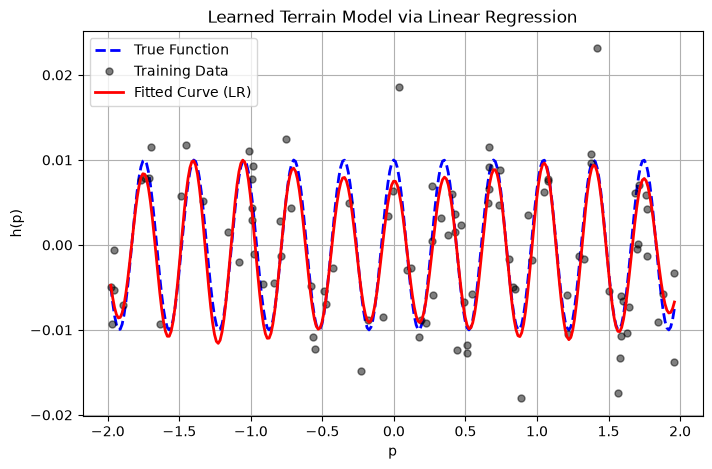

In [49]:
# Generate the training data
np.random.seed(49) # for reproducibility
data_gen = GenerateData(num_samples=100, case=case_real, param=terrain_param)
data_gen.set_noise(mean=0.0, std=0.005) # (I.I.D.) zero-mean Gaussian noise
p, h = data_gen.generate_data()


# Generate basis functions
basis, p_sym, basis_sym = generate_basis_functions(include_offset, include_polynomial, include_trigonometric, 
                                                   min_poly_order, max_poly_order, min_freq, max_freq)

# Fit the model using linear regression
model_lr = Identifier_LR(basis)
model_lr.fit(p, h)


# Visualize the results
true_func = data_gen.get_symbolic_function()
model_lr.plot(true_func=true_func, title="Learned Terrain Model via Linear Regression")


# Generate the symbolic expression for the learned model
h_func_lr, _, _ = construct_casadi_expression(p_sym, basis_sym, model_lr.theta)

In [50]:
# Real case for simulation
env_id = Env(case_real, np.array([initial_position, initial_velocity]), np.array([target_position, target_velocity]),
                 symbolic_h_mean_ext=h_func_lr, param=terrain_param, 
                 state_lbs=state_lbs, state_ubs=state_ubs, input_lbs=input_lbs, input_ubs=input_ubs)
dynamics_id = Dynamics(env_id)

field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.
External functions generated in 5.026 ms.
Templated solver code generated in 788.146 ms.
rm -f libacados_ocp_solver_ocp_MPC_identified_20260825_161900_d262bdab.dylib
rm -f acados_solver_ocp_MPC_identified_20260825_161900_d262bdab.o
cc -fPIC -std=c99   -O2 -I/Users/siqizhou/.acados/include -I/Users/siqizhou/.acados/include/acados -I/Users/siqizhou/.acados/include/blasfeo/include -I/Users/siqizhou/.acados/include/hpipm/include  -c -o acados_solver_ocp_MPC_identified_20260825_161900_d262bdab.o acados_solver_ocp_MPC_identified_20260825_161900_d262bdab.c
cc -fPIC -std=c99   -O2 -I/Users/siqizhou/.acados/include -I/Users/siqizhou/.acados/include/acados -I/Users/siqizhou/.acados/include/blasfeo/include -I/Users/siqizhou/.acados/include/hpipm/include  -c -o MPC_identified_20260825_161900_model/MPC_identified_20

ld: warning: search path '-l' not found


Simulation finished, will start plotting


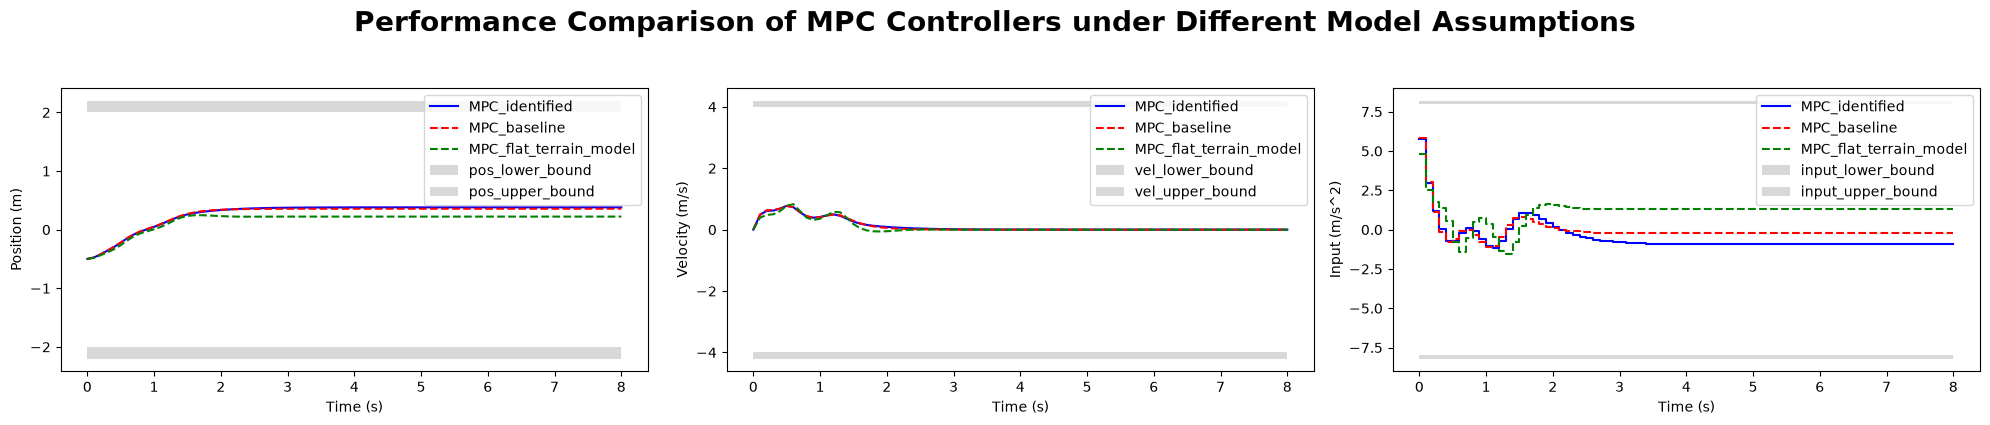

In [51]:
# Define the MPC controller
controller_mpc_identified = MPCController(env_id, dynamics_id, Q, R, Qf, freq, N, name='MPC_identified', verbose=False)

# Instantiate the simulator, run the simulation, and plot the results
simulator_mpc_identified = Simulator(dynamics_real, controller_mpc_identified, env_real, 1/freq, t_terminal)
simulator_mpc_identified.run_simulation()

# Instantiate the visualizer, and display the plots and animation
visualizer_mpc_identified = Visualizer(simulator_mpc_identified)
visualizer_mpc_identified.display_contrast_plots(simulator_mpc_ideal, simulator_mpc_real, title="Performance Comparison of MPC Controllers under Different Model Assumptions")
visualizer_mpc_identified.display_contrast_animation(simulator_mpc_ideal, simulator_mpc_real)

#### **Results Analysis**

The simulation result highlights the performance of the MPC using an identified model (blue) compared to the ideal model (red) and a mismatched flat model (green). The identified controller achieves nearly the same tracking accuracy and control efficiency as the ideal case, demonstrating that a well-learned model from data can effectively recover high performance. In contrast, the flat model leads to steady-state error and larger inputs due to model mismatch.

<br>

----

### **Part 3: Probabilistic Model Learning and Control**

In this section, we address the challenge of controlling systems under uncertainty by leveraging probabilistic model learning and robust control strategies. Unlike previous parts where either the true model or a deterministic learned model was used, here we explicitly account for model uncertainty—either by assuming bounded disturbances or by learning a probabilistic model from data. We first demonstrate RMPC using a mismatched flat model with relatively large uncertainty bounds, and then introduce Bayesian linear regression to quantify model uncertainty and enable learning-based MPC (LBMPC) with constraint tightening.

<br>

#### **Example 3.1: Robust MPC with Flat Model and Bounded Uncertainty**

In this example, we assume the controller designer does not know the true terrain profile and instead simplifies it as flat. However, unlike previous cases that ignore the modeling error, here we explicitly consider that the mismatch between the flat model and reality is bounded. We specify a box-type disturbance set with:

$$
w_1 \in \mathcal{D}_1 = [-0.4, 0.4], \quad w_2 \in \mathcal{D}_2 = [-0.8, 0.8]
$$

representing our prior belief about how much the unmodeled dynamics can deviate. With this uncertainty set, we design an **RMPC** that tightens the constraints based on worst-case disturbance propagation. This ensures that safety constraints are satisfied at all times, even in the presence of the assumed disturbance. The resulting controller is then evaluated in the real bumpy environment to assess performance under model uncertainty.


field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.
External functions generated in 3.397 ms.
Templated solver code generated in 979.925 ms.
rm -f libacados_ocp_solver_ocp_RMPC_flat_terrain_model_20260825_161903_7109433d.dylib
rm -f RMPC_flat_terrain_model_20260825_161903_constraints/RMPC_flat_terrain_model_20260825_161903_constr_h_0_fun_jac_uxt_zt.o RMPC_flat_terrain_model_20260825_161903_constraints/RMPC_flat_terrain_model_20260825_161903_constr_h_0_fun.o RMPC_flat_terrain_model_20260825_161903_constraints/RMPC_flat_terrain_model_20260825_161903_constr_h_fun_jac_uxt_zt.o RMPC_flat_terrain_model_20260825_161903_constraints/RMPC_flat_terrain_model_20260825_161903_constr_h_fun.o RMPC_flat_terrain_model_20260825_161903_constraints/RMPC_flat_terrain_model_20260825_161903_constr_h_e_fun_jac_uxt_zt.o RMPC_flat_terrain_model_20260825_161903_constraints/RMPC_fl

ld: warning: search path '-l' not found


Simulation finished, will start plotting


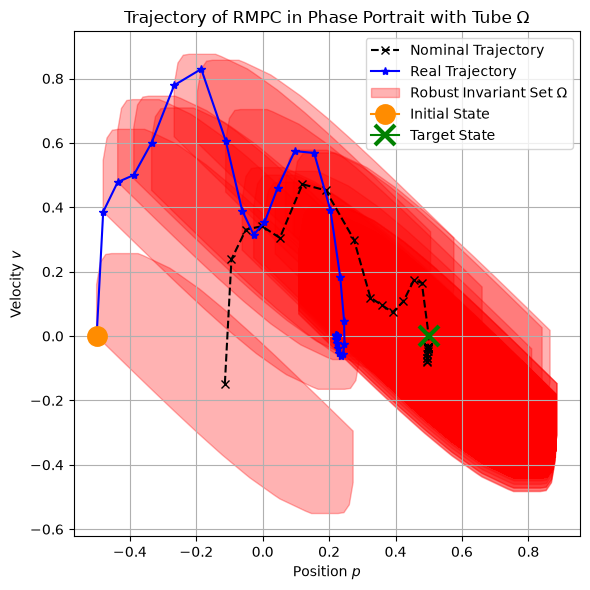

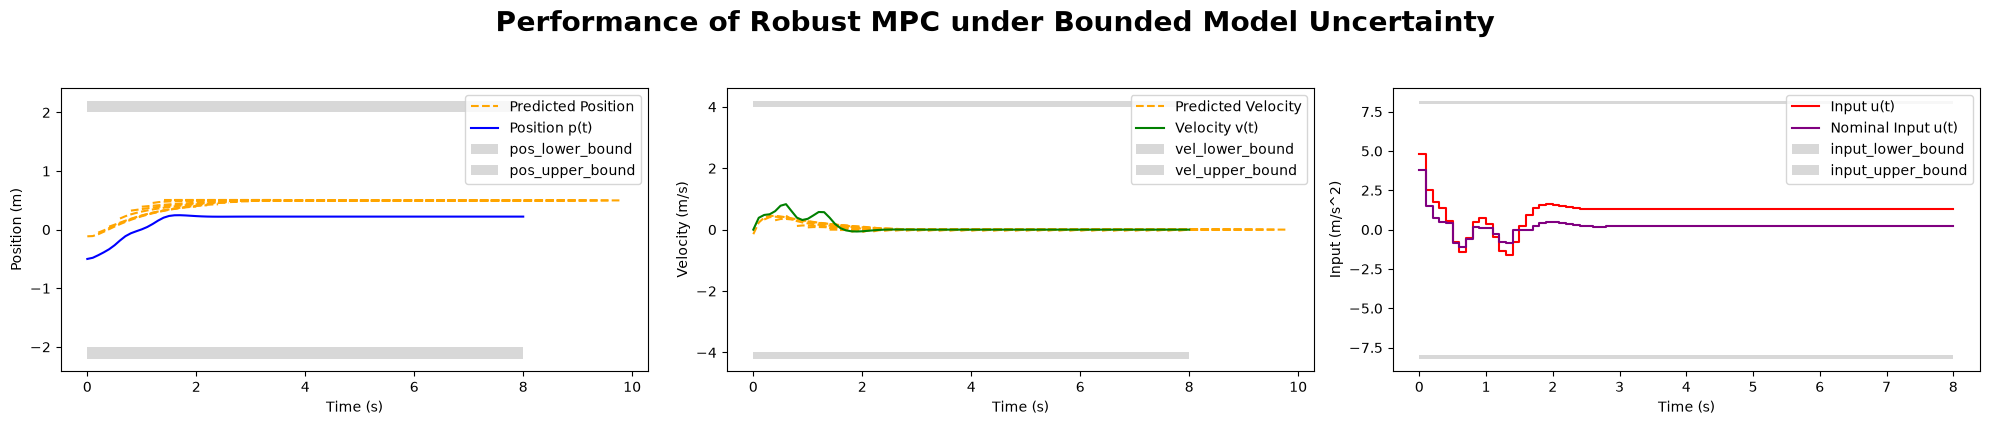

In [52]:
# Define the bounds for the disturbances
disturbance_lbs = np.array([-0.4, -0.8])
disturbance_ubs = np.array([0.4, 0.8])

# Define the RMPC controller
controller_rmpc = LinearRMPCController(env_ideal, dynamics_ideal, Q, R, Qf, freq, N, 
                                       disturbance_bounds=[disturbance_lbs, disturbance_ubs], max_iter=10, name = 'RMPC_flat_terrain_model', verbose=False)

# Instantiate the simulator, run the simulation, and plot the results
simulator_rmpc = Simulator(dynamics_real, controller_rmpc, env_real, 1/freq, t_terminal)
simulator_rmpc.run_simulation()

# Instantiate the visualizer, and display the plottings and animation
visualizer_rmpc = Visualizer(simulator_rmpc)
visualizer_rmpc.display_phase_portrait()
visualizer_rmpc.display_plots("Performance of Robust MPC under Bounded Model Uncertainty")
visualizer_rmpc.display_animation()

#### **Results Analysis**

In this example, the nominal state trajectory successfully converges to the target position, demonstrating that the RMPC optimization works as intended under the assumed flat model. However, due to the presence of the robust invariant tube, the true state is only guaranteed to stay within a neighborhood around the nominal trajectory. Since the stabilizing feedback controller was designed based on the flat terrain dynamics, it may not generate sufficient corrective inputs on the actual terrain to drive the true state exactly to the target. As a result, we observe a steady-state error in the true trajectory. This illustrates a key limitation of RMPC: while it ensures constraint satisfaction and robustness, it may fail to achieve precise convergence in the presence of unmodeled dynamics.

<br>

#### **Example 3.2: Learning-based MPC via Bayesian Model Identification**

In this example, we address the problem of controlling a system when the true environment is unknown and potentially complex, such as a bumpy terrain profile. Instead of assuming a fixed disturbance bound (as in RMPC), we collect data and apply **Bayesian linear regression (BLR)** to learn a **probabilistic model** of the terrain, capturing both the mean and the uncertainty of the terrain profile $ h(p) $. This learned probabilistic model is then integrated into an MPC framework. The core idea is to use the **mean prediction** of the BLR model to correct the dynamics and use the **predicted variance** to perform **constraint tightening**, ensuring that state constraints are satisfied with high probability.

We begin by assuming the system dynamics can be written as:

$$
\dot{\boldsymbol{x}} = \bar{f}(\boldsymbol{x}, \boldsymbol{u}) + \mu^{\text{LM}}(\boldsymbol{x}, \boldsymbol{u}) + \boldsymbol{w} \,,
$$

where:

- $ \bar{f}(\boldsymbol{x}, \boldsymbol{u}) $: prior nominal dynamics,

- $ \mu^{\text{LM}}(\boldsymbol{x}, \boldsymbol{u}) $: learned mean correction from the BLR model,

- $ \boldsymbol{w} \sim \mathcal{N}(0, \Sigma^w) $: zero-mean Gaussian process noise.

&nbsp;&nbsp;&nbsp;&nbsp;*Note that here we do not use a prior model, but directly identify the whole dynamics, i.e., $\bar{f}(\boldsymbol{x}, \boldsymbol{u}) = 0$.*

To implement learning-based MPC, we discretize the above and define the predicted mean state as:

$$
\mu^{\boldsymbol{x}}_{k+i+1|k} = \bar{f}(\mu^{\boldsymbol{x}}_{k+i|k}, \boldsymbol{u}_{k+i|k}) + \mu^{\text{LM}}(\mu^{\boldsymbol{x}}_{k+i|k}, \boldsymbol{u}_{k+i|k})
$$

This gives us the **deterministic state prediction** based on both prior knowledge and the learned mean correction.


To safely handle constraints under uncertainty, we **propagate the state covariance** across the prediction horizon. Using first-order uncertainty propagation, the covariance is updated as:

$$
\Sigma^{\boldsymbol{x}}_{k+i+1|k} = 
\left[
\begin{array}{cc}
\nabla^{\top}_{\boldsymbol{x}} \bar{f}(\mu^{\boldsymbol{x}}_{k+i|k}, \boldsymbol{u}_{k+i|k}) & \mathbf{I}
\end{array}
\right]
\left[
\begin{array}{cc}
\Sigma^{\boldsymbol{x}}_{k+i|k} & \star \\
\nabla_{\boldsymbol{x}} \mu^{\text{LM}} (\mu^{\boldsymbol{x}}_{k+i|k}, \boldsymbol{u}_{k+i|k}) \Sigma^{\boldsymbol{x}}_{k+i|k}  & \Sigma^{\text{LM}}(\mu^{\boldsymbol{x}}_{k+i|k}, \boldsymbol{u}_{k+i|k}) + \Sigma^{\boldsymbol{w}}
\end{array}
\right]
\left[
\begin{array}{c}
\nabla_{\boldsymbol{x}} \bar{f}(\mu^{\boldsymbol{x}}_{k+i|k}, \boldsymbol{u}_{k+i|k}) \\
\mathbf{I}
\end{array}
\right] \,,
$$

where $ \Sigma^{\text{LM}} $ is the learned covariance from BLR.


We then use this covariance to perform **constraint tightening**. Let the original state constraint set be $ \mathcal{X} $. Consider the uncertainty set $\mathcal{R}^x$ as:

$$
\mathcal{R}^{\boldsymbol{x}} = \left\{ \boldsymbol{x} \in \mathbb{R}^n : |[e^x_i]|_j < r \sqrt{[\Sigma^x]_{j,j}}, \quad \forall j = 1, \dots, n \right\} \,,
$$

which defines a high-probability ellipsoidal confidence region around the predicted mean. The final **tightened constraint** for use in MPC is:

$$
\mu^{\boldsymbol{x}}_{k+i|k} \in \mathcal{X} \ominus \mathcal{R}^{\boldsymbol{x}} \,.
$$

This ensures that the true state lies within the original constraint set with high probability (e.g., $ p_x = 0.997 $ when $ r = 3 $).


Finally, we formulate the deterministic LBMPC problem as:

$$
\min_{\boldsymbol{u}_{k|k}, \dots, \boldsymbol{u}_{k+N-1|k}} \ell_N(\mu^{\boldsymbol{x}}_{k+N|k}) + \sum_{i=0}^{N-1} \ell_i(\mu^{\boldsymbol{x}}_{k+i|k}, \boldsymbol{u}_{k+i|k})
$$

subject to:

$$
\mu^{\boldsymbol{x}}_{k+i+1|k} = \bar{f}(\mu^{\boldsymbol{x}}_{k+i|k}, \boldsymbol{u}_{k+i|k}) + \mu^{\text{LM}}(\mu^{\boldsymbol{x}}_{k+i|k}, \boldsymbol{u}_{k+i|k}), \quad \forall i = \{0, 1, ..., N-1\},
$$
$$
\Sigma^{\boldsymbol{x}}_{k+i+1|k} \leftarrow \text{ updated via the first-order approximation} \,,
$$
$$
\mu^{\boldsymbol{x}}_{k+i|k} \in \mathcal{X} \ominus \mathcal{R}^{\boldsymbol{x}}(\Sigma^{\boldsymbol{x}}_{k+i|k}), \quad \forall i = \{0, 1, ..., N-1\},
$$
$$
\boldsymbol{u}_{k+i|k} \in \mathcal{U}, \quad \forall i = \{0, 1, ..., N-1\},
$$
$$
\mu^{\boldsymbol{x}}_{k|k} = \boldsymbol{x}_k, \quad \Sigma^{\boldsymbol{x}}_{k|k} = 0.
$$


Through this setup, **LBMPC** ensures that both prediction and control account for model uncertainty, leading to improved safety and reduced conservatism compared to RMPC. The learned uncertainty from BLR drives the tightening, allowing a **data-efficient and probabilistically safe** control solution. We implement this data-driven controller as the following class:

In [53]:
class LearningBasedMPCController(LQRController):
    def __init__(self, 
                 env: Env, 
                 dynamics: Dynamics, 
                 Q: np.ndarray, 
                 R: np.ndarray, 
                 Qf: np.ndarray, 
                 N: int, 
                 freq: float, 
                 beta: float = 3.0, 
                 Sigma_w: np.ndarray = None, 
                 name: str = 'LBMPC',
                 type: str = 'MPC', 
                 verbose: bool = True):

        self.Qf = Qf
        self.N = N
        self.beta = beta # default for beta is 3.0, which corresponds to 3-sigma rule

        super().__init__(env, dynamics, Q, R, freq, name, type, verbose)

        if self.env.h_cov is None:
            raise ValueError("Dynamics variance function must be provided for LBMPC.")
        else:
            self.dynamics.build_stochastic_model(self.dt)

        self.Sigma_w = Sigma_w if Sigma_w is not None else np.zeros((self.dim_states, self.dim_inputs))

    def setup(self):

        ## Model
        # Set up Acados model
        model = AcadosModel()
        model.name = self.name

        # Define model: x_dot = f(x, u)
        model.x = self.dynamics.states
        model.u = self.dynamics.inputs
        model.f_expl_expr = ca.vertcat(self.dynamics.dynamics_function(self.dynamics.states, self.dynamics.inputs))
        model.f_impl_expr = None # not needed, we already have the explicit model

        ocp = AcadosOcp()
        ocp.model = model
        ocp.dims.N = self.N
        ocp.solver_options.tf = self.N * self.dt
        ocp.solver_options.qp_solver = "FULL_CONDENSING_HPIPM"
        ocp.solver_options.integrator_type = "ERK"
        ocp.solver_options.nlp_solver_type = "SQP"

        # Set up other hyperparameters in SQP solving
        ocp.solver_options.nlp_solver_max_iter = 100
        ocp.solver_options.nlp_solver_tol_stat = 1E-6
        ocp.solver_options.nlp_solver_tol_eq = 1E-6
        ocp.solver_options.nlp_solver_tol_ineq = 1E-6
        ocp.solver_options.nlp_solver_tol_comp = 1E-6

        ocp.cost.cost_type = "LINEAR_LS"
        ocp.cost.cost_type_e = "LINEAR_LS"

        ocp.cost.W = np.block([
            [self.Q, np.zeros((self.dim_states, self.dim_inputs))],
            [np.zeros((self.dim_inputs, self.dim_states)), self.R]
        ])
        ocp.cost.W_e = self.Qf

        ocp.cost.Vx = np.block([
            [np.eye(self.dim_states)],
            [np.zeros((self.dim_inputs, self.dim_states))]
        ])
        ocp.cost.Vu = np.block([
            [np.zeros((self.dim_states, self.dim_inputs))],
            [np.eye(self.dim_inputs)]
        ])
        ocp.cost.Vx_e = np.eye(self.dim_states)

        ocp.cost.yref = np.zeros(self.dim_states + self.dim_inputs)
        ocp.cost.yref_e = np.zeros(self.dim_states)

        # Define constraints
        ocp.constraints.idxbx_0 = np.arange(self.dim_states)
        ocp.constraints.idxbx = np.arange(self.dim_states)
        ocp.constraints.idxbx_e = np.arange(self.dim_states)
        ocp.constraints.idxbu = np.arange(self.dim_inputs)
        
        ocp.constraints.lbx_0 = np.array(self.env.state_lbs)
        ocp.constraints.ubx_0 = np.array(self.env.state_ubs)
        ocp.constraints.lbx = np.array(self.env.state_lbs)
        ocp.constraints.ubx = np.array(self.env.state_ubs)
        ocp.constraints.lbx_e = np.array(self.env.state_lbs)
        ocp.constraints.ubx_e = np.array(self.env.state_ubs)
        ocp.constraints.lbu = np.array(self.env.input_lbs)
        ocp.constraints.ubu = np.array(self.env.input_ubs)

        self.ocp = ocp
        self.solver = AcadosOcpSolver(ocp, json_file=f"{self.name}.json")

    def propagate_uncertainty(self, x, u, Sigma_curr):
        Sigma_next = self.dynamics.dynamics_variance_function_disc(x, u) + self.Sigma_w
        return Sigma_next

    def tighten_state_constraints(self, Sigma_x):
        r = self.beta
        diag = np.sqrt(np.diag(Sigma_x))
        if self.verbose:
            print(f"Tightening state constraints with beta={self.beta}, diag={diag}")
        return self.env.state_lbs + r * diag, self.env.state_ubs - r * diag

    def compute_action(self, current_state: np.ndarray, current_time):
        self.solver.set(0, "lbx", current_state)
        self.solver.set(0, "ubx", current_state)

        # === Step 1: Use previous rollout to predict mean state/control sequence ===
        mu_x_seq = [current_state]
        mu_u_seq = []

        for i in range(self.N):
            # Use last solved control prediction if available, otherwise use zeros
            if hasattr(self, "last_u_pred"):
                mu_u = self.last_u_pred[i]
            else:
                mu_u = np.zeros(self.dim_inputs)
            mu_x = mu_x_seq[-1]

            # Compute next state mean via dynamics
            mu_x_next = self.dynamics.one_step_forward(mu_x, mu_u, self.dt)  # should match rollout model
            mu_x_seq.append(mu_x_next)
            mu_u_seq.append(mu_u)

        # === Step 2: Propagate uncertainty along predicted trajectory ===
        Sigma_x_seq = [np.zeros((self.dim_states, self.dim_states))]

        for i in range(self.N):
            Sigma_x_next = self.propagate_uncertainty(
                mu_x_seq[i], mu_u_seq[i], Sigma_x_seq[i]
            )
            Sigma_x_seq.append(Sigma_x_next)

        # === Step 3: Apply constraint tightening and set to Acados ===
        ref = np.concatenate((self.env.target_state, np.zeros(self.dim_inputs)))
        for i in range(1, self.N):
            # Set reference
            self.solver.set(i, "yref", ref)

            # # Tighten constraints based on propagated covariance
            lbx_tight, ubx_tight = self.tighten_state_constraints(Sigma_x_seq[i])
            self.solver.set(i, "lbx", lbx_tight)
            self.solver.set(i, "ubx", ubx_tight)
            if self.verbose:
                print(f"Step {i}: lbx={lbx_tight}, ubx={ubx_tight}")

        self.solver.set(self.N, "yref", self.env.target_state)
        lbx_tight, ubx_tight = self.tighten_state_constraints(Sigma_x_seq[self.N])
        self.solver.set(self.N, "lbx", lbx_tight)
        self.solver.set(self.N, "ubx", ubx_tight)
        if self.verbose:
            print(f"Final step: lbx={lbx_tight}, ubx={ubx_tight}")

        # === Step 4: Solve MPC ===
        status = self.solver.solve()
        #if status != 0:
        #    raise ValueError(f"Acados solver failed with status {status}")

        u_opt = self.solver.get(0, "u")
        x_pred = np.array([self.solver.get(i, "x") for i in range(self.N + 1)])
        u_pred = np.array([self.solver.get(i, "u") for i in range(self.N)])

        # Cache rollout for next time
        self.last_u_pred = u_pred.copy()
        self.last_x_pred = x_pred.copy()

        return u_opt, x_pred, u_pred

We instantiate the learning-based MPC method developed above and evaluate its performance through simulation. The parameter settings used in the system identification phase are listed below.

- **Reference Arguments for Basis Function Configuration:**

    - Include offset: `True`

    - Include polynomial terms: `False`

    - Include trigonometric terms: `True`

    - Minimum frequency: `16`

    - Maximum frequency: `20`.

- **Reference Arguments for Data Generation:**

    - Number of samples: `1000`

    - Measurement noise: zero-mean Gaussian, standard deviation $\sigma$ as `0.005`.

In [54]:
# Define the prior parameters
sigma_prior = 0.005

# Define basis functions
include_offset=True
include_polynomial=False
include_trigonometric=True
min_poly_order=1
max_poly_order=1
min_freq=16
max_freq=20

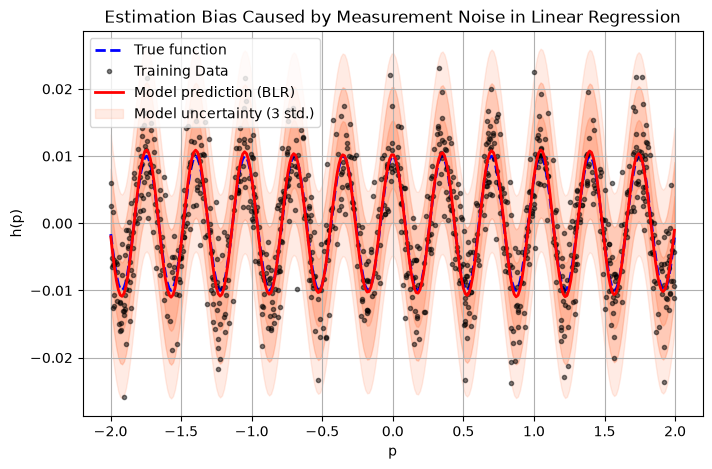

In [55]:
# Generate the training data
np.random.seed(49) # for reproducibility
data_gen = GenerateData(num_samples=1000, case=case_real, param=terrain_param)
data_gen.set_noise(mean=0.0, std=sigma_prior) # (I.I.D.) zero-mean Gaussian noise
p, h = data_gen.generate_data()


# Generate basis functions
basis, p_sym, basis_sym = generate_basis_functions(include_offset, include_polynomial, include_trigonometric, 
                                                   min_poly_order, max_poly_order, min_freq, max_freq)

# Fit the model using linear regression
model_blr = Identifier_BLR(basis, sigma2=sigma_prior**2)
model_blr.fit(p, h)


# Visualize the results
true_func = data_gen.get_symbolic_function()
model_blr.plot(true_func=true_func, title="Estimation Bias Caused by Measurement Noise in Linear Regression")


# Generate the symbolic expression for the learned model
h_func_blr, sigma2_h_func_blr, sigma2_dh_func_blr = construct_casadi_expression(p_sym, basis_sym, model_blr.theta, model_blr.Sigma_theta, sigma_prior**2)


# Identified case for simulation
env_id = Env(case_real, np.array([initial_position, initial_velocity]), np.array([target_position, target_velocity]),
                 symbolic_h_mean_ext=h_func_blr, symbolic_h_cov_ext=sigma2_h_func_blr,
                 symbolic_dh_cov_ext=sigma2_dh_func_blr, param=terrain_param,
                 state_lbs=state_lbs, state_ubs=state_ubs, input_lbs=input_lbs, input_ubs=input_ubs)
dynamics_id = Dynamics(env_id)


Check passed, Q is a symmetric, positive semi-definite matrix.
Check passed, R is a symmetric, positive definite matrix.
field AcadosOcpDims.N has been migrated to AcadosOcpOptions.N_horizon. setting AcadosOcpOptions.N_horizon = N. For future comppatibility, please use AcadosOcpOptions.N_horizon directly.
External functions generated in 1.464 ms.


/var/folders/f3/gm0kzm7s32j50ml2fczt0z0c0000gn/T/ipykernel_68799/353410863.py:95: DeprecationWarning:  The `json_file` argument is deprecated in v0.5.6 and will be removed in a future release. Set AcadosOcp.code_gen_options.json_file instead.
  self.solver = AcadosOcpSolver(ocp, json_file=f"{self.name}.json")


Templated solver code generated in 767.812 ms.
rm -f libacados_ocp_solver_ocp_LBMPC_8fa0cc67.dylib
rm -f acados_solver_ocp_LBMPC_8fa0cc67.o
cc -fPIC -std=c99   -O2 -I/Users/siqizhou/.acados/include -I/Users/siqizhou/.acados/include/acados -I/Users/siqizhou/.acados/include/blasfeo/include -I/Users/siqizhou/.acados/include/hpipm/include  -c -o acados_solver_ocp_LBMPC_8fa0cc67.o acados_solver_ocp_LBMPC_8fa0cc67.c
cc -fPIC -std=c99   -O2 -I/Users/siqizhou/.acados/include -I/Users/siqizhou/.acados/include/acados -I/Users/siqizhou/.acados/include/blasfeo/include -I/Users/siqizhou/.acados/include/hpipm/include  -c -o LBMPC_model/LBMPC_expl_ode_fun.o LBMPC_model/LBMPC_expl_ode_fun.c
cc -fPIC -std=c99   -O2 -I/Users/siqizhou/.acados/include -I/Users/siqizhou/.acados/include/acados -I/Users/siqizhou/.acados/include/blasfeo/include -I/Users/siqizhou/.acados/include/hpipm/include  -c -o LBMPC_model/LBMPC_expl_vde_forw.o LBMPC_model/LBMPC_expl_vde_forw.c
cc -fPIC -std=c99   -O2 -I/Users/siqizhou/.a

ld: warning: search path '-l' not found


Tightening state constraints with beta=3.0, diag=[0.         0.00041153]
Step 1: lbx=[-2.        -3.9987654], ubx=[2.        3.9987654]
Tightening state constraints with beta=3.0, diag=[0.         0.00042932]
Step 2: lbx=[-2.         -3.99871205], ubx=[2.         3.99871205]
Tightening state constraints with beta=3.0, diag=[0.         0.00046859]
Step 3: lbx=[-2.         -3.99859424], ubx=[2.         3.99859424]
Tightening state constraints with beta=3.0, diag=[0.         0.00049443]
Step 4: lbx=[-2.         -3.99851672], ubx=[2.         3.99851672]
Tightening state constraints with beta=3.0, diag=[0.         0.00048471]
Step 5: lbx=[-2.         -3.99854586], ubx=[2.         3.99854586]
Tightening state constraints with beta=3.0, diag=[0.         0.00046055]
Step 6: lbx=[-2.         -3.99861835], ubx=[2.         3.99861835]
Tightening state constraints with beta=3.0, diag=[0.         0.00045788]
Step 7: lbx=[-2.         -3.99862637], ubx=[2.         3.99862637]
Tightening state constra

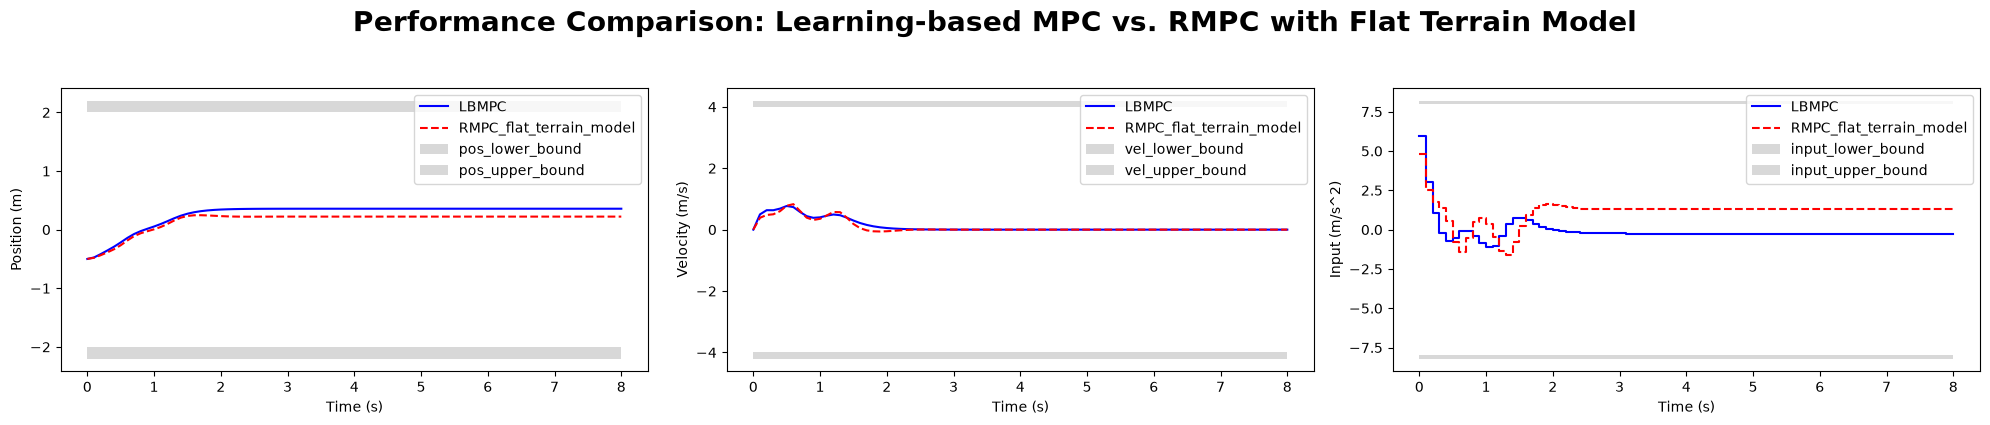

In [56]:
# Define the LBMPC controller
controller_lbmpc = LearningBasedMPCController(env_id, dynamics_id, Q, R, Qf, N, freq, name='LBMPC')

# Instantiate the simulator, run the simulation, and plot the results
simulator_lbmpc = Simulator(dynamics_real, controller_lbmpc, env_real, 1/freq, t_terminal)
simulator_lbmpc.run_simulation()

# Instantiate the visualizer, and display the plots and animation
visualizer_lbmpc = Visualizer(simulator_lbmpc)
visualizer_lbmpc.display_contrast_plots(simulator_rmpc, title="Performance Comparison: Learning-based MPC vs. RMPC with Flat Terrain Model")
visualizer_lbmpc.display_contrast_animation(simulator_rmpc)


#### **Results Analysis**

Compared to RMPC, LBMPC accurately reaches the target state, whereas RMPC only stabilizes within a neighborhood due to its conservative design. This performance gap arises because RMPC is based on a flat terrain model and fails to generate enough thrust to overcome the slope. In contrast, LBMPC captures the slope profile through Bayesian learning, enabling more informed predictions and tighter control actions. As a result, LBMPC achieves lower steady-state error and more efficient input usage under the same constraints.

<br>

<br>

----

### **Part 4: Gaussian Process Learning and Control**

Every model we have learned so far was handed a strong hint. The basis functions used in Parts 2 and 3 already encoded that the terrain is periodic with a frequency somewhere between 16 and 20, so the identification problem was reduced to finding eleven coefficients. That hint is exactly the *structure* of the model, and it is fair to ask how much of the good behaviour we saw was due to the learning algorithm and how much was due to the structure we quietly gave it.

In this part we drop the hint. We compare the structured Bayesian linear regression model against a **Gaussian process (GP)**, the standard black-box choice for learning robot dynamics, and then embed the GP model in an MPC to see what the difference costs in closed loop.

<br>

#### **Example 4.1: Comparing GP and Bayesian Linear Regression for Model Learning**

Both models are Bayesian and both return a mean and a variance, but they place their prior in very different places.

**Bayesian linear regression** puts the prior on a finite set of coefficients,

$$
h(p) = \boldsymbol{\phi}(p)^\top \boldsymbol{\theta}, \qquad \boldsymbol{\theta} \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0),
$$

so the predictive variance at a test point, $\boldsymbol{\phi}(p)^\top \boldsymbol{\Sigma}_{\boldsymbol{\theta}} \boldsymbol{\phi}(p)$, depends on the data only through $\boldsymbol{\Sigma}_{\boldsymbol{\theta}}$. Once the data pins down the coefficients *anywhere*, the model is confident *everywhere* the basis is valid.

**Gaussian process regression** puts the prior directly on the function, with no basis at all,

$$
h(p) \sim \mathcal{GP}\big(0,\; k(p, p')\big), \qquad k(p, p') = \sigma_f^2 \exp\!\left(-\frac{(p - p')^2}{2\ell^2}\right),
$$

and the posterior variance at a test point grows back towards the prior $\sigma_f^2$ as soon as that point is more than a few lengthscales $\ell$ away from any data. Its confidence is *local*.

This difference is invisible when the training data covers the whole operating range, which is why it did not show up in Examples 2.1 and 3.2. To expose it, we collect data over $p \in [-2, -0.5] \cup [0.5, 2]$ and leave a **gap** in the middle: a stretch of terrain the car never visited during data collection. We then ask both models to predict over the full range $p \in [-2, 2]$, and we judge them on two separate questions:

- Is the **mean** right? Measured by the RMS prediction error against the true terrain.

- Is the **error bar** right? Measured by the normalized error $z = (h_{\text{true}} - \mu) / \sigma$. A well-calibrated model has $\mathrm{RMS}(z) \approx 1$. If $\mathrm{RMS}(z) > 1$ the model is **overconfident**, its bounds are too tight, and any constraint tightening built on them is unsafe. If $\mathrm{RMS}(z) \ll 1$ the model is **over-conservative**, its bounds are valid but so wide that the resulting MPC will refuse to move.

Note that we compare against the **epistemic** (model) uncertainty only, dropping the measurement-noise term $\sigma_n^2$ from the predictive variance. Our uncertainty about the terrain itself is what propagates into constraint tightening; the noise in a future measurement of it is not.

- **Reference Arguments for Data Generation:**

    - Sampling region: $p \in [-2, -0.5] \cup [0.5, 2]$, with no data for $p \in [-0.5, 0.5]$

    - Number of samples: `150`

    - Measurement noise: zero-mean Gaussian, standard deviation $\sigma$ as `0.005`.

- **Reference Arguments for the two models:**

    - BLR basis: offset and trigonometric terms, frequencies `16` to `20` (identical to Example 3.2)

    - GP kernel: squared exponential, with $\ell$ and $\sigma_f$ tuned on the same data by maximizing the log marginal likelihood.

We tune the GP hyperparameters by marginal likelihood rather than fixing them by hand, so the comparison is as favourable to the black-box model as it can reasonably be.


In [57]:
class Identifier_GP:
    """
    Gaussian process regression with a squared-exponential (RBF) kernel.

    This is the 'black-box' counterpart to Identifier_BLR. It assumes only that the
    terrain is smooth, not that it is periodic, so all of its structural knowledge
    is carried by two hyperparameters: the lengthscale (how fast h(p) may vary) and
    the signal standard deviation (how large h(p) may be).
    """

    def __init__(self, lengthscale=0.1, signal_std=0.01, noise_std=0.005):
        self.lengthscale = lengthscale  # l
        self.signal_std = signal_std    # sigma_f
        self.noise_std = noise_std      # sigma_n
        self.p_train = None
        self.h_train = None

    def _kernel(self, pa, pb):
        d = pa.reshape(-1, 1) - pb.reshape(1, -1)
        return self.signal_std**2 * np.exp(-0.5 * (d / self.lengthscale)**2)

    def log_marginal_likelihood(self, p, h):
        """Evidence of the data under the current hyperparameters."""
        p, h = np.asarray(p).ravel(), np.asarray(h).ravel()
        K = self._kernel(p, p) + (self.noise_std**2 + 1e-12) * np.eye(len(p))
        L = np.linalg.cholesky(K)
        alpha = np.linalg.solve(L.T, np.linalg.solve(L, h))
        return float(-0.5 * h @ alpha - np.sum(np.log(np.diag(L))) - 0.5 * len(p) * np.log(2 * np.pi))

    def optimize_hyperparameters(self, p, h, lengthscales=None, signal_stds=None):
        """Grid search on the log marginal likelihood: the standard, fair way to tune a GP."""
        lengthscales = np.logspace(-2, np.log10(2.0), 50) if lengthscales is None else lengthscales
        signal_stds = np.logspace(np.log10(5e-4), -1, 40) if signal_stds is None else signal_stds
        best_lml, best_hp = -np.inf, (self.lengthscale, self.signal_std)
        for l in lengthscales:
            for s in signal_stds:
                self.lengthscale, self.signal_std = l, s
                lml = self.log_marginal_likelihood(p, h)
                if lml > best_lml:
                    best_lml, best_hp = lml, (l, s)
        self.lengthscale, self.signal_std = best_hp
        return best_hp, best_lml

    def fit(self, p, h):
        self.p_train = np.asarray(p).reshape(-1, 1)
        self.h_train = np.asarray(h).reshape(-1, 1)
        p_flat = self.p_train.ravel()
        K = self._kernel(p_flat, p_flat) + (self.noise_std**2 + 1e-12) * np.eye(len(p_flat))
        self.L = np.linalg.cholesky(K)
        self.alpha = np.linalg.solve(self.L.T, np.linalg.solve(self.L, self.h_train.ravel()))

    def predict(self, p, include_noise=True):
        p = np.asarray(p).reshape(-1, 1)
        Ks = self._kernel(p.ravel(), self.p_train.ravel())
        mean = (Ks @ self.alpha).reshape(-1, 1)
        v = np.linalg.solve(self.L, Ks.T)
        var = self.signal_std**2 - np.sum(v**2, axis=0).reshape(-1, 1)
        if include_noise:
            var = var + self.noise_std**2
        return mean, np.sqrt(np.maximum(var, 1e-18))

In [58]:
def epistemic_prediction(model, p_test):
    """
    Mean prediction and *model* (epistemic) uncertainty, excluding the measurement-noise
    term. This is the quantity that matters for constraint tightening: our uncertainty
    about the terrain itself, not about a future noisy measurement of it.
    """
    if isinstance(model, Identifier_GP):
        mean, std = model.predict(p_test, include_noise=False)
    else:  # Identifier_BLR
        mean, std_obs = model.predict(p_test)
        std = np.sqrt(np.maximum(std_obs**2 - model.sigma2, 1e-18))
    return mean.ravel(), std.ravel()


def plot_model(model, p_test, true_func, ax, gap=None, title=None, legend=True, ylim=(-0.05, 0.05)):
    """Draw one model's mean and 1/2/3-sigma bands. Identical for BLR and GP, so the
    two panels of the comparison can be read against each other directly."""
    mean, std = epistemic_prediction(model, p_test)
    p_flat = p_test.ravel()

    if gap is not None:
        ax.axvspan(gap[0], gap[1], color='gray', alpha=0.15, zorder=0)
    ax.plot(p_flat, [float(true_func(p)) for p in p_flat], 'b--', linewidth=2, label='True function')
    ax.plot(model.p_train, model.h_train, 'k.', alpha=0.5, markersize=8, label='Training data')
    ax.plot(p_flat, mean, color='red', linewidth=2, label='Model prediction')
    for i in range(1, 4):
        ax.fill_between(p_flat, mean - i*std, mean + i*std, color='coral',
                        alpha=0.15 if i == 3 else 0.3,
                        label='Model uncertainty (3 std.)' if i == 3 else None)
    ax.set_xlabel('p'); ax.set_ylabel('h(p)'); ax.grid(True)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if title:
        ax.set_title(title, fontsize=11)
    if legend:
        ax.legend(fontsize=8, loc='lower left')


def calibration_report(models, labels, p_test, true_func, gap):
    """
    Compare the error a model actually makes against the error bar it claims.

    With z = (h_true - mean) / std, a well-calibrated model has RMS(z) close to 1.
    RMS(z) > 1 means overconfident (bounds too tight, so constraint tightening based
    on them is unsafe); RMS(z) < 1 means over-conservative (bounds valid but so wide
    they carry little information).
    """
    h_true = np.array([float(true_func(p)) for p in p_test.ravel()])
    in_gap = (p_test.ravel() > gap[0]) & (p_test.ravel() < gap[1])

    print(f"{'model':<34}{'region':<12}{'RMS error':>11}{'mean std':>11}{'RMS z':>8}{'2-sigma cov.':>14}")
    print("-" * 90)
    for model, label in zip(models, labels):
        mean, std = epistemic_prediction(model, p_test)
        for region_name, mask in (("with data", ~in_gap), ("in the gap", in_gap)):
            err = h_true[mask] - mean[mask]
            z = err / std[mask]
            print(f"{label:<34}{region_name:<12}{np.sqrt(np.mean(err**2)):>11.5f}"
                  f"{np.mean(std[mask]):>11.5f}{np.sqrt(np.mean(z**2)):>8.2f}"
                  f"{100*np.mean(np.abs(z) < 2):>13.1f}%")
    print("-" * 90)
    print(f"RMS amplitude of the true terrain inside the gap: {np.sqrt(np.mean(h_true[in_gap]**2)):.5f} "
          f"(a model predicting only zero scores exactly this).")
    print("Nominal 2-sigma coverage for a calibrated Gaussian model: 95.4%.")

GP hyperparameters from marginal likelihood: lengthscale = 0.0780, signal std = 0.00757


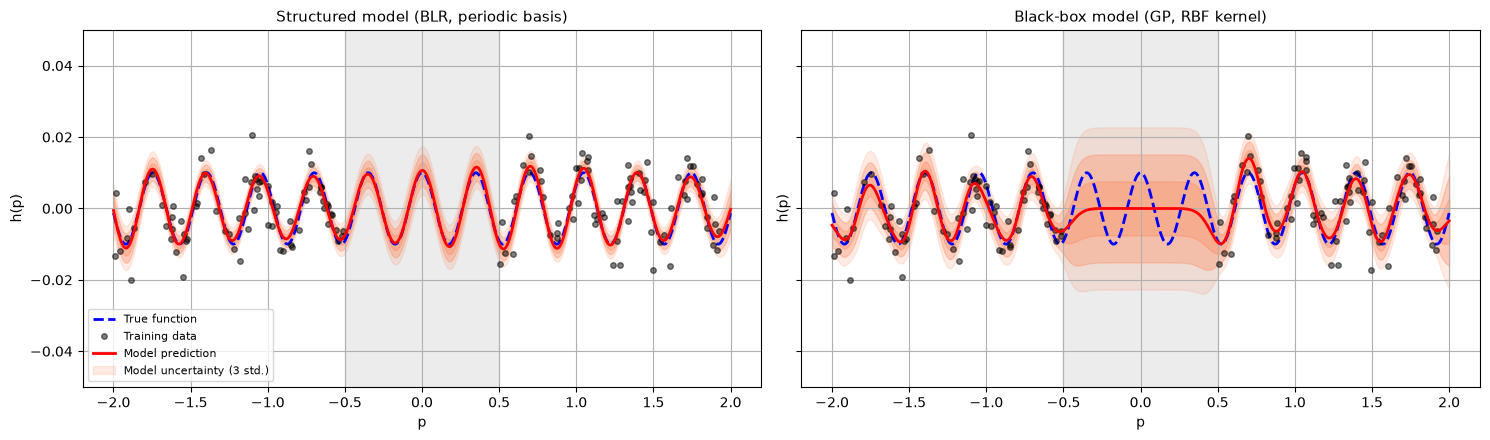

In [59]:
# Collect data everywhere except a gap in the middle: the region the car never visited
gap = (-0.5, 0.5)
num_samples_gp = 150
sigma_gp = 0.005 # measurement noise std

np.random.seed(49) # for reproducibility
data_gen_gp = GenerateData(p_range=[(-2.0, gap[0]), (gap[1], 2.0)], num_samples=num_samples_gp,
                           case=case_real, param=terrain_param)
data_gen_gp.set_noise(mean=0.0, std=sigma_gp) # (I.I.D.) zero-mean Gaussian noise
p_gap, h_gap = data_gen_gp.generate_data()


# Structured model: BLR on the same trigonometric basis used in Example 3.2
basis_gp, p_sym_gp, basis_sym_gp = generate_basis_functions(include_offset=True, include_polynomial=False,
                                                            include_trigonometric=True, min_freq=16, max_freq=20)
model_blr_gap = Identifier_BLR(basis_gp, sigma2=sigma_gp**2)
model_blr_gap.fit(p_gap, h_gap)


# Black-box model: GP whose hyperparameters are tuned on the same data
model_gp = Identifier_GP(noise_std=sigma_gp)
(hp_l, hp_sf), _ = model_gp.optimize_hyperparameters(p_gap, h_gap)
model_gp.fit(p_gap, h_gap)
print(f"GP hyperparameters from marginal likelihood: lengthscale = {hp_l:.4f}, signal std = {hp_sf:.5f}")


# Compare both models over the full domain, including the region without data
p_test = np.linspace(-2.0, 2.0, 801).reshape(-1, 1)
true_func = data_gen_gp.get_symbolic_function()

_, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)
plot_model(model_blr_gap, p_test, true_func, axes[0], gap=gap, title="Structured model (BLR, periodic basis)")
plot_model(model_gp, p_test, true_func, axes[1], gap=gap, title="Black-box model (GP, RBF kernel)", legend=False)
plt.tight_layout()
plt.show()

In [60]:
calibration_report([model_blr_gap, model_gp],
                   ["BLR (structured)", "GP (black box, tuned)"],
                   p_test, true_func, gap)

model                             region        RMS error   mean std   RMS z  2-sigma cov.
------------------------------------------------------------------------------------------
BLR (structured)                  with data       0.00101    0.00139    0.74        100.0%
BLR (structured)                  in the gap      0.00077    0.00205    0.39        100.0%
GP (black box, tuned)             with data       0.00200    0.00238    0.86         97.7%
GP (black box, tuned)             in the gap      0.00704    0.00713    0.95        100.0%
------------------------------------------------------------------------------------------
RMS amplitude of the true terrain inside the gap: 0.00691 (a model predicting only zero scores exactly this).
Nominal 2-sigma coverage for a calibrated Gaussian model: 95.4%.


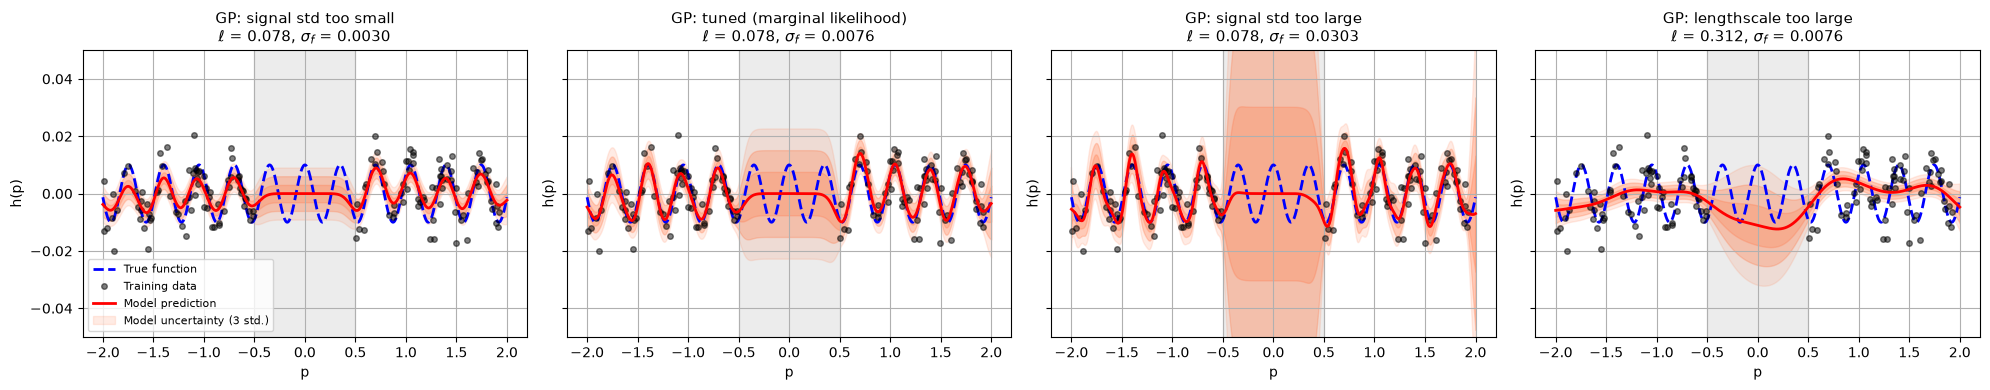

model                             region        RMS error   mean std   RMS z  2-sigma cov.
------------------------------------------------------------------------------------------
GP: signal std too small          with data       0.00355    0.00178    1.97         57.8%
GP: signal std too small          in the gap      0.00691    0.00294    2.30         44.2%
GP: tuned (marginal likelihood)   with data       0.00200    0.00238    0.86         97.7%
GP: tuned (marginal likelihood)   in the gap      0.00704    0.00713    0.95        100.0%
GP: signal std too large          with data       0.00231    0.00312    0.80         97.2%
GP: signal std too large          in the gap      0.00697    0.02735    0.24        100.0%
GP: lengthscale too large         with data       0.00719    0.00136    5.53         20.1%
GP: lengthscale too large         in the gap      0.01221    0.00510    2.56         49.2%
BLR (structured)                  with data       0.00101    0.00139    0.74        100.0%

In [61]:
# Same data, same kernel: only the two hyperparameters move away from their tuned values
hyper_variants = [
    (hp_l,     hp_sf / 2.5, "signal std too small"),
    (hp_l,     hp_sf,       "tuned (marginal likelihood)"),
    (hp_l,     hp_sf * 4.0, "signal std too large"),
    (hp_l*4.0, hp_sf,       "lengthscale too large"),
]

gp_variants, gp_labels = [], []
_, axes = plt.subplots(1, len(hyper_variants), figsize=(20, 4.0), sharey=True)
for ax, (l, sf, name) in zip(axes, hyper_variants):
    gp_v = Identifier_GP(lengthscale=l, signal_std=sf, noise_std=sigma_gp)
    gp_v.fit(p_gap, h_gap)
    plot_model(gp_v, p_test, true_func, ax, gap=gap,
               title=f"GP: {name}\n$\\ell$ = {l:.3f}, $\\sigma_f$ = {sf:.4f}", legend=(ax is axes[0]))
    gp_variants.append(gp_v)
    gp_labels.append(f"GP: {name}")
plt.tight_layout()
plt.show()

calibration_report(gp_variants + [model_blr_gap], gp_labels + ["BLR (structured)"],
                   p_test, true_func, gap)

#### **Results Analysis**

**The structured model generalizes across the gap; the black-box model does not.** Inside the gap the BLR model reaches an RMS error of about `0.0008`, while the GP reaches about `0.0070`. The second number is essentially the RMS amplitude of the terrain itself (`0.0069`), which is the score of a model that predicts nothing but zero: the GP has reverted to its prior mean and learned nothing about the unvisited stretch. The BLR model, in contrast, is roughly an order of magnitude better there than a zero prediction, because the periodic basis lets data collected on both sides determine the phase and amplitude in the middle. This is the sense in which the right structure makes generalization easy: the terrain never had to be observed at $p = 0$ for the model to know what it looks like.

**With the right structure, the bounds are realistic.** The BLR error bar in the gap is about `0.0021` and still covers the truth. The GP error bar is about `0.0071`, more than three times wider, and it is only valid because the model has given up. Both are "safe", but they are not equally useful: propagated through the constraint tightening of Example 3.2, the GP bound would demand more than three times the margin in exactly the region where the car has no data and most needs to act.

**The black-box bounds are only as good as their calibration.** The final experiment keeps the data and the kernel fixed and moves only the two hyperparameters. The failure is not graceful:

- $\sigma_f$ too small: 2-sigma coverage falls to about `44%` in the gap against a nominal `95.4%`, with $\mathrm{RMS}(z) \approx 2.3$. The model is confidently wrong, which is the dangerous direction for a safety bound.

- $\ell$ too large: the GP smooths straight through the oscillation, reports very small variance where it has plenty of data, and its coverage collapses to about `20%` with $\mathrm{RMS}(z) \approx 5.5$.

- $\sigma_f$ too large: coverage returns to `100%`, but the bound in the gap inflates to about `0.027`, roughly thirteen times the BLR bound, which is conservative to the point of being useless.

Only the marginal-likelihood setting is close to calibrated, and finding it required an optimization over the training set. The structured model needs no such tuning: its uncertainty is inherited from the posterior over eleven coefficients, and it stays informative and valid in all four comparisons.

The practical reading for learning-based control is not that GPs are a poor choice. It is that a black-box model buys freedom from modelling assumptions at the price of a calibration step, and that the calibration must be trusted before its variance is used to tighten a constraint. Where genuine structural knowledge exists, encoding it in the model buys both a better mean and a tighter honest bound for free. In Example 4.2 we take the tuned GP into closed loop and see how these differences play out in the resulting trajectories.

<br>


<br>

#### **Example 4.2: Model Learning When the Basis Is Misspecified**

Example 4.1 was, in one important respect, rigged in favour of the structured model: the basis contained the true function. The frequency of the terrain is 18, and we handed the regression a band from 16 to 20. It is worth asking what happens when that assumption is wrong, because in practice the whole point of a structural assumption is that it is made *before* the data is seen.

We keep the data, the noise level and the gap exactly as in Example 4.1, and change only the frequency band of the basis:

- **Basis too narrow** (frequencies 8 to 20 excluded, band 8 to 12): the true frequency lies outside the span, so no choice of coefficients can reproduce the terrain. The model error is now **bias**, not noise.

- **Basis correct** (band 16 to 20): the reference case from Example 4.1.

- **Basis very broad** (band 1 to 25, 51 basis functions): the natural hedge against misspecification. The truth is comfortably inside the span, but so is a great deal else.

The quantity to watch is the same normalized error $z = (h_{\text{true}} - \mu)/\sigma$ as before. There is a specific reason to expect trouble in the first case. The BLR posterior covariance

$$
\boldsymbol{\Sigma}_{\boldsymbol{\theta}} = \left( \boldsymbol{\Sigma}_0^{-1} + \tfrac{1}{\sigma^2}\boldsymbol{\Phi}^\top\boldsymbol{\Phi} \right)^{-1}
$$

depends on the regressor matrix $\boldsymbol{\Phi}$ and on the assumed noise variance $\sigma^2$, but **never on the residuals**. The model computes its error bars from how much data it has and where, not from how well it actually fits. If the residual is bias rather than noise, the posterior has no mechanism to notice, and the reported uncertainty will be just as tight as in the well-specified case. A Gaussian process is not immune to this either, but tuning $\sigma_f$ by marginal likelihood does give it one channel through which a large residual can widen the bounds.

- **Reference Arguments:**

    - Data, noise and gap: identical to Example 4.1 (`150` samples, $\sigma$ = `0.005`, no data on $p \in [-0.5, 0.5]$)

    - Basis variants: trigonometric with offset, frequency bands `8-12`, `16-20` and `1-25`

    - GP: the tuned model from Example 4.1, shown unchanged for reference.


BLR: basis too narrow   -> 11 basis functions (8-12 Hz)
BLR: basis is correct   -> 11 basis functions (16-20 Hz)
BLR: basis very broad   -> 51 basis functions (1-25 Hz)


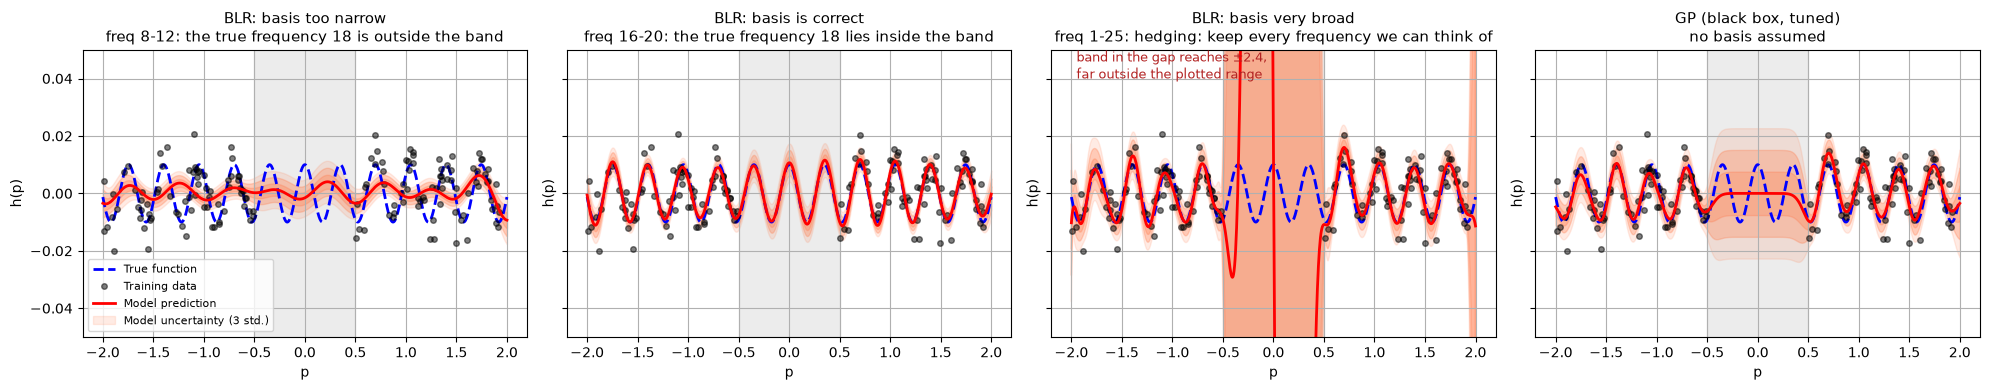

In [62]:
# Three structural assumptions, all fitted to exactly the same data as Example 4.1
basis_variants = [
    ("basis too narrow",  dict(min_freq=8,  max_freq=12), "the true frequency 18 is outside the band"),
    ("basis is correct",  dict(min_freq=16, max_freq=20), "the true frequency 18 lies inside the band"),
    ("basis very broad",  dict(min_freq=1,  max_freq=25), "hedging: keep every frequency we can think of"),
]

blr_variants, blr_labels = [], []
for name, freq_kwargs, _ in basis_variants:
    basis_v, _, _ = generate_basis_functions(include_offset=True, include_polynomial=False,
                                             include_trigonometric=True, **freq_kwargs)
    model_v = Identifier_BLR(basis_v, sigma2=sigma_gp**2)
    model_v.fit(p_gap, h_gap)
    blr_variants.append(model_v)
    blr_labels.append(f"BLR: {name}")
    print(f"BLR: {name:18s} -> {len(basis_v):2d} basis functions ({freq_kwargs['min_freq']}-{freq_kwargs['max_freq']} Hz)")

# Plot all three against the tuned GP of Example 4.1, on a common scale
_, axes = plt.subplots(1, 4, figsize=(20, 4.0), sharey=True)
for ax, model_v, (name, freq_kwargs, note) in zip(axes, blr_variants, basis_variants):
    plot_model(model_v, p_test, true_func, ax, gap=gap,
               title=f"BLR: {name}\nfreq {freq_kwargs['min_freq']}-{freq_kwargs['max_freq']}: {note}",
               legend=(ax is axes[0]))
plot_model(model_gp, p_test, true_func, axes[3], gap=gap,
           title="GP (black box, tuned)\nno basis assumed", legend=False)
axes[2].annotate("band in the gap reaches $\\pm 2.4$,\nfar outside the plotted range", xy=(-1.95, 0.040),
                 ha='left', fontsize=9, color='firebrick')
plt.tight_layout()
plt.show()

In [63]:
calibration_report(blr_variants + [model_gp], blr_labels + ["GP (black box, tuned)"],
                   p_test, true_func, gap)

model                             region        RMS error   mean std   RMS z  2-sigma cov.
------------------------------------------------------------------------------------------
BLR: basis too narrow             with data       0.00697    0.00140    5.42         21.1%
BLR: basis too narrow             in the gap      0.00741    0.00221    3.31         29.6%
BLR: basis is correct             with data       0.00101    0.00139    0.74        100.0%
BLR: basis is correct             in the gap      0.00077    0.00205    0.39        100.0%
BLR: basis very broad             with data       0.00219    0.00416    0.81         95.8%
BLR: basis very broad             in the gap      0.37737    2.41032    0.15        100.0%
GP (black box, tuned)             with data       0.00200    0.00238    0.86         97.7%
GP (black box, tuned)             in the gap      0.00704    0.00713    0.95        100.0%
------------------------------------------------------------------------------------------

In [64]:
def blr_log_marginal_likelihood(model, p, h):
    """
    Evidence of the data under a BLR model: h ~ N(Phi mu0, sigma^2 I + Phi Sigma0 Phi^T).

    Unlike the posterior variance, this quantity does depend on the residuals, so it can
    tell us that a basis is wrong even though the error bars cannot.
    """
    p = np.asarray(p).reshape(-1, 1)
    h = np.asarray(h).reshape(-1, 1)
    Phi = np.hstack([f(p) for f in model.basis_functions])
    B = Phi.shape[1]
    mu0 = model.mu0_user if model.mu0_user is not None else np.zeros((B, 1))
    Sigma0 = model.Sigma0_user if model.Sigma0_user is not None else np.eye(B)

    C = model.sigma2 * np.eye(len(p)) + Phi @ Sigma0 @ Phi.T
    L = np.linalg.cholesky(C)
    r = h - Phi @ mu0
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, r))
    return float(-0.5 * (r.T @ alpha).item() - np.sum(np.log(np.diag(L))) - 0.5 * len(p) * np.log(2 * np.pi))


print(f"{'model':<34}{'log evidence':>14}")
print("-" * 48)
for model_v, label in zip(blr_variants, blr_labels):
    print(f"{label:<34}{blr_log_marginal_likelihood(model_v, p_gap, h_gap):>14.1f}")
print(f"{'GP (black box, tuned)':<34}{model_gp.log_marginal_likelihood(p_gap, h_gap):>14.1f}")
print("-" * 48)
print("Higher is better. The comparison among the three BLR rows is the fair one: they share\n"
      "the same noise model and none of their hyperparameters were tuned on this data. The GP\n"
      "row is optimistic by construction, since its two hyperparameters were chosen in\n"
      "Example 4.1 by maximizing exactly this number.")

model                               log evidence
------------------------------------------------
BLR: basis too narrow                      367.5
BLR: basis is correct                      499.3
BLR: basis very broad                      347.6
GP (black box, tuned)                      534.6
------------------------------------------------
Higher is better. The comparison among the three BLR rows is the fair one: they share
the same noise model and none of their hyperparameters were tuned on this data. The GP
row is optimistic by construction, since its two hyperparameters were chosen in
Example 4.1 by maximizing exactly this number.


#### **Results Analysis**

**A wrong basis fails silently, which is the worst way to fail.** With the band 8 to 12 the model cannot represent the terrain at all: its RMS error is `0.0070` even in the region densely covered by data, which is no better than predicting zero. Yet its reported error bar there is `0.0014`, almost identical to the `0.0014` reported by the correctly specified model. The result is $\mathrm{RMS}(z) \approx 5.4$ and a 2-sigma coverage of `21%` against a nominal `95.4%`. The model is not merely wrong, it is wrong while claiming the same precision it would have if it were right. Feeding that variance into the constraint tightening of Example 3.2 would produce a controller that is confident, aggressive, and unsafe.

Note that this failure is visible **inside the training region**, not only in the gap. Nothing about collecting more data fixes it: the error is bias, and more samples only shrink $\boldsymbol{\Sigma}_{\boldsymbol{\theta}}$ further, making the bound tighter and the overconfidence worse.

**Hedging with a broad basis restores honesty but destroys the generalization.** The 51-function model fits the data region well (RMS error `0.0022`, coverage `96%`, close to nominal) because the truth is inside its span. In the gap, however, the near-collinearity of 25 frequencies over a finite window leaves the coefficients only weakly determined, and the prediction diverges wildly: RMS error `0.377`, roughly fifty times the amplitude of the terrain. To its credit the model reports this, with a gap error bar of `2.41` and full coverage. But a bound of $\pm 2.41$ on a terrain of amplitude `0.01` is not a bound anyone can act on. Broadening the basis converted a confidently wrong model into an honest but useless one, and in the process gave up exactly the extrapolation that made the structured approach attractive.

**This is the tradeoff.** Ranking the four models in the gap:

| model | RMS error | error bar | verdict |
| --- | --- | --- | --- |
| BLR, basis too narrow | 0.0074 | 0.0022 | wrong, and confidently so — unsafe |
| BLR, basis correct | 0.0008 | 0.0021 | accurate and tight — the payoff for correct structure |
| BLR, basis very broad | 0.377 | 2.41 | honest but uninformative |
| GP, tuned | 0.0070 | 0.0071 | uninformative in the gap, but never badly wrong |

Structure is leverage, and leverage cuts both ways. When it is right it buys an order of magnitude in accuracy and a threefold tighter bound over the black box. When it is wrong it produces the one failure mode a safety-critical controller cannot tolerate. The GP occupies the middle: it was never the best model in any region, but it was never dangerously wrong either, and that graceful degradation is what the calibration effort of Example 4.1 actually buys.

**The bound cannot detect misspecification, but the evidence can.** The last cell computes the log marginal likelihood of the data under each basis. The correct band scores `499.3`, against `367.5` for the too-narrow basis and `347.6` for the over-broad one, so the evidence ranks the three assumptions correctly even though the error bars do not distinguish them at all. This suggests the practical discipline for learning-based control: the posterior variance answers *"given that my model class is right, how sure am I?"*, and it must not be used to answer *"is my model class right?"*. That second question needs a separate check — marginal likelihood, held-out residuals, or cross-validation — and it should be answered before the variance is ever used to tighten a constraint.


<blockquote style="
    padding: 18px 20px;
    margin: 1.2em 0;
    background: rgba(56, 139, 253, 0.12);      
    border-left: 4px solid rgba(56, 139, 253, 0.85);
    border-radius: 6px;
    color: inherit !important;                  
">

##### **Takeaway:**

- When the **true model is known**, classic model-based control performs optimally.  

- In practice, **model mismatch is unavoidable**. Naively reusing old controllers or applying RMPC with rough bounds often leads to failure (e.g., steady-state errors). 

- **Learning a model from data** is key:

  - **Linear regression (LR)** gives a deterministic approximation.

  - **Bayesian linear regression (BLR)** further captures uncertainty for safer control.
  
- With a properly identified model, especially probabilistic ones, **learning-based MPC (LBMPC)** can restore near-optimal performance and enable **constraint tightening** under uncertainty.

</blockquote>
